This notebook characterizes the different species based on their absorption spectra, using a MLP.

In [1]:
import sys
import os
import torch
import torch.nn as nn
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Set a nice default style
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['font.size'] = 12
sys.path.insert(0, os.path.abspath("../.."))
from build_spectra.linear_combination import generate_mixture_spectra

In [2]:
df = pd.read_excel('../../../data/spectral_library_clean.xlsx')
df.ffill(axis=0, inplace=True)
df.bfill(axis=0, inplace=True)  # handles leading NaNs

wavelength = df['Wavelength']
abs_spectra = df.iloc[:, 1:].to_numpy().T

In [3]:
def data_creation(N_training_, N_validation_, noise_level_, abs_spectra_):
    # set seed for reproduction purposes
    N_species = len(abs_spectra_)
    N_wavelengths = len(wavelength)
    X = torch.zeros(N_species, (N_training_ + N_validation_), N_wavelengths)
    y = torch.zeros(N_species, (N_training_ + N_validation_), dtype=torch.long) # class needs integer 

    for specie_index, spectra in enumerate(abs_spectra_):
        data = torch.zeros(N_training_ + N_validation_, N_wavelengths)
        
        for i in range(N_training_ + N_validation_):
            data[i, :] = torch.tensor(spectra, dtype=torch.float32) + noise_level_ * torch.randn(N_wavelengths)

        X[specie_index] = data
        y[specie_index] = torch.zeros(N_training_ + N_validation_, dtype=torch.long) + int(specie_index)

    # shuffle first
    perm = torch.randperm(X.shape[1])
    X, y = X[:, perm, :], y[:, perm]
    
    # compute stats on training portion only
    mean = X[:, :N_training_, :].mean(dim=(1,2), keepdim=True)
    std  = X[:, :N_training_, :].std(dim=(1,2),  keepdim=True) + 1e-8

    # normalize full dataset
    X_norm = (X - mean) / std

    # split up datasets into training and validation
    X_train_, y_train_ = X_norm[:, :N_training_, :], y[:, :N_training_]
    X_val_,   y_val_   = X_norm[:, N_training_:, :], y[:, N_training_:]
    return X_train_, y_train_, X_val_, y_val_

In [4]:
noise_level = .1
N_training = 4000
N_validation = int(N_training * .2)
X_train, y_train, X_val, y_val = data_creation(N_training, N_validation, noise_level, abs_spectra)

In [5]:
def training_loop(nr_epochs, epochs_no_improvement, X_train_, y_train_, X_val_, y_val_):
    N_species = len(y_val_)
    # tested several models, model_3 works best
    model_1 = nn.Sequential(
    nn.Linear(len(wavelength), 64),
    nn.ReLU(),
    nn.Linear(64, N_species)
    )
    model_2 = nn.Sequential(
    nn.Linear(len(wavelength), 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, N_species)
    )
    model_3 = nn.Sequential(
    nn.Linear(len(wavelength), 128),
    nn.ReLU(),
    nn.Linear(128, N_species)
    )

    model = model_3
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    # changes learning rate for better learning
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=20, factor = 0.5, min_lr = 1e-6)
    
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs   = []
    epochs_list = []
    class_choice_val_list = []
    prob_val_list = []

    X_train_ = X_train_.reshape(-1, len(wavelength))        # (9*200, 451) = (1800, 451)
    X_val_ = X_val_.reshape(-1,len(wavelength))
    y_train_ = y_train_.reshape(-1)           # (1800,)
    y_val_ = y_val_.reshape(-1)

    best_val_loss = float('inf')

    for epoch in range(nr_epochs):
        model.train()
        optimizer.zero_grad()

        pred = model(X_train_).squeeze()
        
        # input should be (Ntraining * Nclasses, Nwavelength)
        loss = nn.CrossEntropyLoss()(pred[:, :], y_train_)
        loss.backward()
        optimizer.step()

        # find probability of logit (pred)
        prob = nn.Softmax(dim=1)(pred)
        class_choice = torch.argmax(prob, dim = 1)

        model.eval()
        with torch.no_grad():
            pred_val = model(X_val_).squeeze() # same shape as y_val
            loss_val = nn.CrossEntropyLoss()(pred_val[:], y_val_)

            prob_val = nn.Softmax(dim=1)(pred_val)
            class_choice_val = torch.argmax(prob_val, dim = 1)
            
        # if true, we return a 1. Else 0.
        train_acc = (class_choice == y_train_).float().mean().item() * 100
        val_acc = (class_choice_val == y_val_).float().mean().item() * 100

        train_losses.append(loss.item())
        val_losses.append(loss_val.item()) 
        train_accs.append(train_acc)
        val_accs.append(val_acc) 
        epochs_list.append(epoch)
        class_choice_val_list.append(class_choice_val)
        prob_val_list.append(prob_val) 

        # if validation loss grows, break loop
        if loss_val.item() < best_val_loss:
            best_val_loss = loss_val.item()
            epochs_without_improvement = 0

        else:
            epochs_without_improvement += 1

        if epochs_without_improvement > epochs_no_improvement:
            print(f"Early stopping at epoch {epoch}")
            break
        scheduler.step(loss_val.item())
    return train_losses, val_losses, train_accs, val_accs, epochs_list, model, class_choice_val_list, y_val_, prob_val_list


In [6]:
train_losses, val_losses, train_accs, val_accs, epochs_list, trained_model, choice_validation, y_validation, prob_validation = training_loop(1000, 0, X_train, y_train, X_val, y_val)

Early stopping at epoch 300


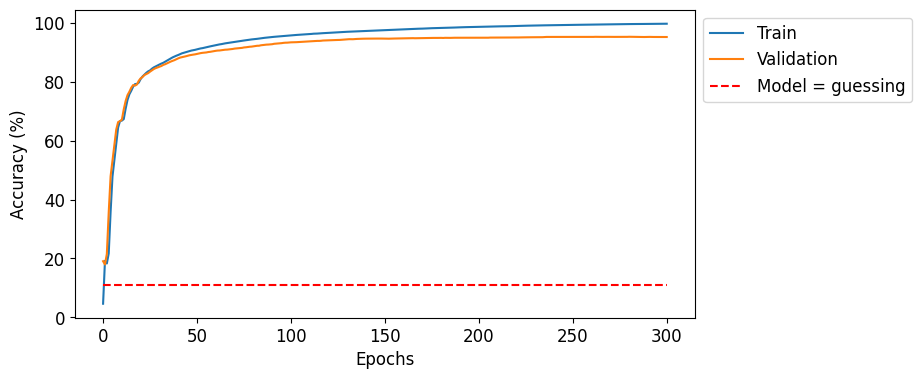

In [7]:
# show accuracy of MLP

plt.plot(epochs_list, train_accs, label = 'Train')
plt.plot(epochs_list, val_accs, label = 'Validation')
plt.hlines(100/9, 0, epochs_list[-1], linestyles='--', color ='red', label = 'Model = guessing')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend(bbox_to_anchor = (1,1))
plt.show()

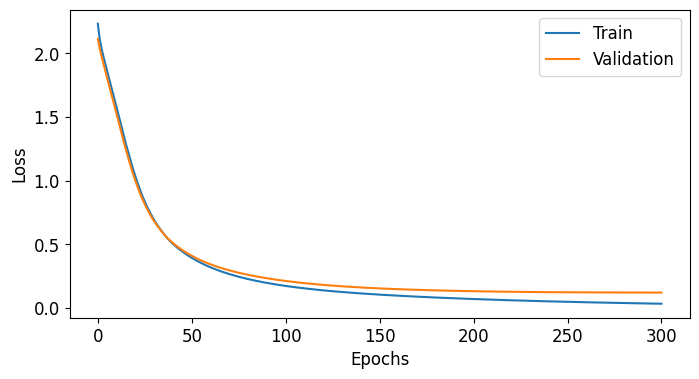

In [8]:
# loss function versus epochs
plt.plot(epochs_list, train_losses, label = 'Train')
plt.plot(epochs_list, val_losses, label = 'Validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In an ideal world, the MLP learns the most important spectral features of their own spectra. So, testing the model on linear combinations of spectra should in theory return the biggest contributor to the linear combination. So, without a concentration MLP we still can predict the order of the contributing strains. This is not what is observed here.

In [9]:
def data_creation_mixed_spectra(noise_level_):
    '''This function outputs a noisy absorption spectrum, normalized with mean and standard deviation.'''
    mixture_spectra_full, weights_spectra = generate_mixture_spectra(df, combination_sizes = (8,9))
    mixture_spectra_full = mixture_spectra_full.to_numpy()

    weight_values = weights_spectra.drop(columns="mixture_name").to_numpy(dtype=float) # shape (600,9) (samples, species)
    mixture_spectra = mixture_spectra_full[:,10:].astype(float).T # shape (600, 451)(samples, wavelengths)
    number_of_samples, _ = mixture_spectra.shape
    
    X = torch.tensor(mixture_spectra, dtype=torch.float32) + noise_level_ * torch.randn(mixture_spectra.shape)
    y = torch.tensor(weight_values, dtype = torch.float32)

    perm = torch.randperm(X.shape[0])

    X, y = X[perm], y[perm]

    # separate into training and validation data
    N_training = int(number_of_samples * .8)
    # N_validation = int(number_of_samples * .2)

    # compute stats on training portion only
    mean = X[:N_training].mean(dim=0)
    std  = X[:N_training].std(dim=0) + 1e-8

    # normalize full dataset
    X_norm = (X - mean) / std

    # split up datasets
    X_train_, y_train_ = X_norm[:N_training],  y[:N_training]
    X_val_,   y_val_   = X_norm[N_training:],  y[N_training:]
    return X_train_, y_train_, X_val_, y_val_

In [10]:
accuracy_list = []
for _ in range(1000):
    X_comb_spectra, y_comb_spectra, _, _ = data_creation_mixed_spectra(noise_level)

    pred_comb = trained_model(X_comb_spectra).squeeze()
    prob_comb = nn.Softmax(dim=1)(pred_comb)
    nr_spectra, _ = X_comb_spectra.shape

    pred_top2 = torch.topk(prob_comb, k=2, dim=1)
    actual_top2 = torch.topk(y_comb_spectra, k = 2, dim = 1)

    pred_first_max = pred_top2.indices[:, 0]  # index of first highest
    actual_first_max = actual_top2.indices[:,0]

    accuracy_first = (pred_first_max == actual_first_max).float().mean().item() * 100
    accuracy_list.append(accuracy_first)
    
print(np.mean(accuracy_list), np.std(accuracy_list))

2.030000030249357 1.0858637277024767


In [11]:
pred_all = torch.topk(prob_comb, k = 9, dim = 1)
actual_all = torch.topk(y_comb_spectra, k = 9, dim = 1)
# checks if whole list is in correct order

accuracy = (pred_all.indices == actual_all.indices).float().mean().item() * 100
print(accuracy)
print(f'Random guess:{100/9}')

11.666666716337204
Random guess:11.11111111111111


Plots to show accuracy of characterization

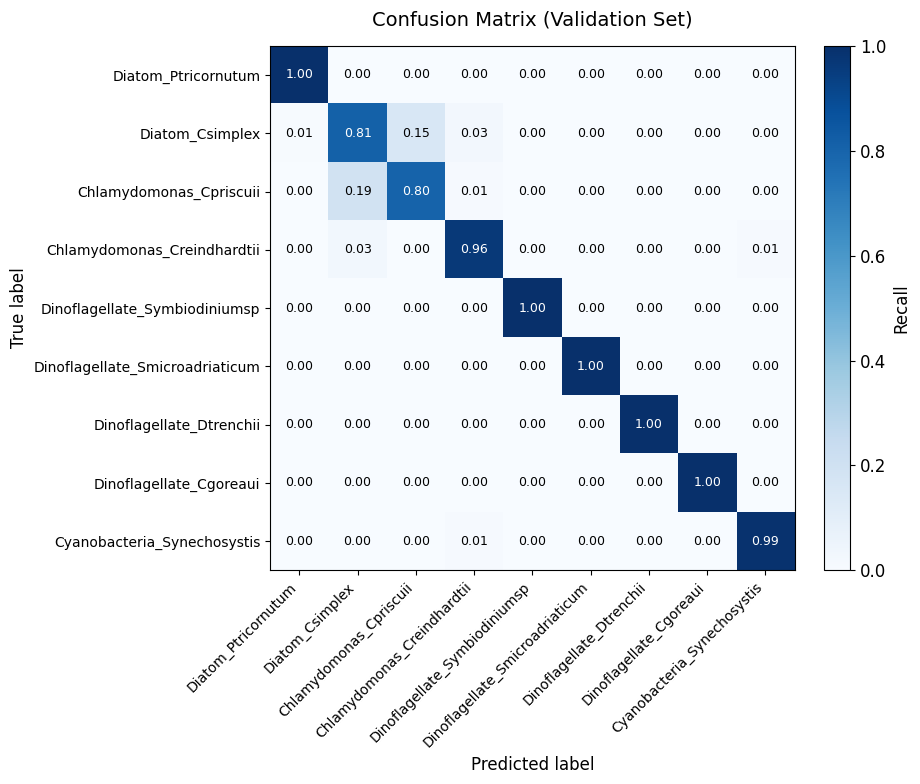

In [12]:
# Get predictions and true labels at last epoch
y_pred = choice_validation[-1].numpy()
y_true = y_validation
species_names = df.columns[1:].tolist()

cm = confusion_matrix(y_true, y_pred, normalize="true")

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)

# colorbar
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Recall", fontsize=12)

# ticks
ax.set_xticks(range(len(species_names)))
ax.set_yticks(range(len(species_names)))
ax.set_xticklabels(species_names, rotation=45, ha="right", fontsize=10)
ax.set_yticklabels(species_names, fontsize=10)

# annotate cells
for i in range(len(species_names)):
    for j in range(len(species_names)):
        color = "white" if cm[i, j] > 0.6 else "black"
        ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center", fontsize=9, color=color)

ax.set_xlabel("Predicted label", fontsize=12)
ax.set_ylabel("True label", fontsize=12)
ax.set_title("Confusion Matrix (Validation Set)", fontsize=14, pad=15)

plt.tight_layout()
plt.show()

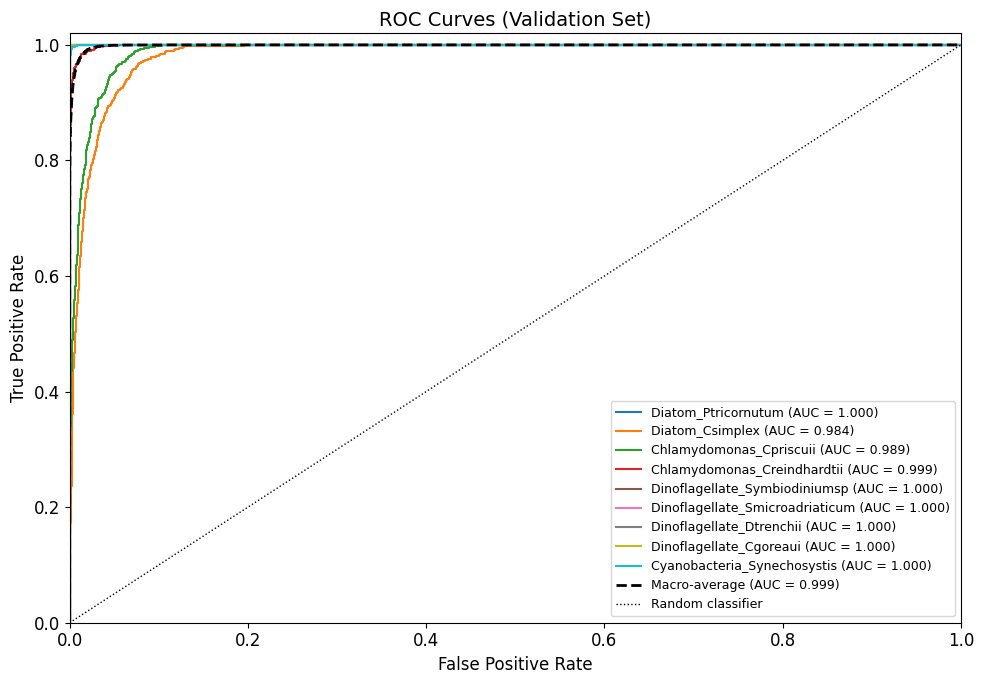

In [13]:
n_classes = len(species_names)

# binarize true labels: (N_val, N_classes)
y_bin = label_binarize(y_true, classes=range(n_classes))
probs = prob_validation[-1].numpy()
# Compute ROC curve and AUC per class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Macro-average AUC
fpr["macro"], tpr["macro"], _ = roc_curve(y_bin.ravel(), probs.ravel())
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Plot
fig, ax = plt.subplots(figsize=(10, 7))

colors = plt.cm.tab10(np.linspace(0, 1, n_classes))
for i, (name, color) in enumerate(zip(species_names, colors)):
    ax.plot(fpr[i], tpr[i], color=color, lw=1.5,
            label=f"{name} (AUC = {roc_auc[i]:.3f})")

ax.plot(fpr["macro"], tpr["macro"], color="black", lw=2, linestyle="--",
        label=f"Macro-average (AUC = {roc_auc['macro']:.3f})")
ax.plot([0, 1], [0, 1], "k:", lw=1, label="Random classifier")

ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curves (Validation Set)", fontsize=14)
ax.legend(loc="lower right", fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()